# Step 1 — Load the Dataset

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/crop_prices_SA_raw.csv", parse_dates=["date"]) # load the data and parse the date column as date type
df 

,date,year,month,week_of_year,season,crop,region,price_per_kg,rainfall_mm,temp_max_c,temp_min_c,humidity_pct,supply_index
0,2020-01-01,2020,1,1,Summer,Maize,Free State,4.26,4.6,23.0,14.1,51.7,0.330
1,2020-01-08,2020,1,2,Summer,Maize,Free State,4.25,13.2,19.5,11.4,52.7,0.406
2,2020-01-15,2020,1,3,Summer,Maize,Free State,4.31,11.1,20.2,11.6,48.3,0.444
3,2020-01-22,2020,1,4,Summer,Maize,Free State,4.27,23.8,22.2,13.7,57.6,0.523
4,2020-01-29,2020,1,5,Summer,Maize,Free State,4.41,14.0,20.9,11.2,53.4,0.296
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5003,2025-11-26,2025,11,48,Spring,Wheat,North West,7.92,0.0,16.8,7.2,42.4,0.485
5004,2025-12-03,2025,12,49,Summer,Wheat,North West,7.72,0.0,19.7,11.0,27.6,0.551
5005,2025-12-10,2025,12,50,Summer,Wheat,North West,7.45,7.5,19.0,11.0,52.1,0.490
5006,2025-12-17,2025,12,51,Summer,Wheat,North West,7.40,3.9,18.2,10.0,38.8,0.507


In [2]:
print("Shape:", df.shape)
print("---------------------------\nColumns:\n", df.columns.tolist())
print("---------------------------------\nData types:\n", df.dtypes)
print("-------------------------------------------------------------------\nFirst 5 rows:\n")
df.head()

Shape: (5008, 13)
---------------------------
Columns:
 ['date', 'year', 'month', 'week_of_year', 'season', 'crop', 'region', 'price_per_kg', 'rainfall_mm', 'temp_max_c', 'temp_min_c', 'humidity_pct', 'supply_index']
---------------------------------
Data types:
 date            datetime64[ns]
year                     int64
month                    int64
week_of_year             int64
season                  object
crop                    object
region                  object
price_per_kg           float64
rainfall_mm            float64
temp_max_c             float64
temp_min_c             float64
humidity_pct           float64
supply_index           float64
dtype: object
-------------------------------------------------------------------
First 5 rows:



,date,year,month,week_of_year,season,crop,region,price_per_kg,rainfall_mm,temp_max_c,temp_min_c,humidity_pct,supply_index
0,2020-01-01,2020,1,1,Summer,Maize,Free State,4.26,4.6,23.0,14.1,51.7,0.330
1,2020-01-08,2020,1,2,Summer,Maize,Free State,4.25,13.2,19.5,11.4,52.7,0.406
2,2020-01-15,2020,1,3,Summer,Maize,Free State,4.31,11.1,20.2,11.6,48.3,0.444
3,2020-01-22,2020,1,4,Summer,Maize,Free State,4.27,23.8,22.2,13.7,57.6,0.523
4,2020-01-29,2020,1,5,Summer,Maize,Free State,4.41,14.0,20.9,11.2,53.4,0.296


# Step 2 — Exploratory Data Analysis (EDA)

In [3]:
# statistics
print("\nBasic statistics:\n")
df.describe().round(2).T


Basic statistics:



,count,mean,min,25%,50%,75%,max,std
date,5008,2022-12-28 00:00:00,2020-01-01 00:00:00,2021-06-30 00:00:00,2022-12-28 00:00:00,2024-06-26 00:00:00,2025-12-24 00:00:00,NaN
year,5008.0,2022.49,2020.0,2021.0,2022.0,2024.0,2025.0,1.71
month,5008.0,6.5,1.0,4.0,7.0,9.0,12.0,3.45
week_of_year,5008.0,26.58,1.0,14.0,27.0,40.0,53.0,15.06
price_per_kg,4910.0,7.36,2.48,5.19,6.83,8.7,21.61,3.31
rainfall_mm,4599.0,9.07,0.0,0.0,0.2,17.7,57.7,11.9
temp_max_c,5008.0,26.27,9.1,21.1,26.4,31.5,40.8,6.15
temp_min_c,4812.0,18.26,0.8,13.1,18.2,23.5,34.4,6.27
humidity_pct,4762.0,47.21,22.0,39.2,44.5,53.98,92.0,10.81
supply_index,4872.0,0.5,0.12,0.43,0.5,0.57,0.88,0.11


In [4]:
def display_info_and_missing_values(df):
    print("Null counts:\n", df.isnull().sum())
    print("\nNull percentage:\n", (df.isnull().sum() / len(df) * 100).round(2))
    
display_info_and_missing_values(df)    

Null counts:
 date              0
year              0
month             0
week_of_year      0
season            0
crop              0
region            0
price_per_kg     98
rainfall_mm     409
temp_max_c        0
temp_min_c      196
humidity_pct    246
supply_index    136
dtype: int64

Null percentage:
 date            0.00
year            0.00
month           0.00
week_of_year    0.00
season          0.00
crop            0.00
region          0.00
price_per_kg    1.96
rainfall_mm     8.17
temp_max_c      0.00
temp_min_c      3.91
humidity_pct    4.91
supply_index    2.72
dtype: float64


#### Price distribution per crop 

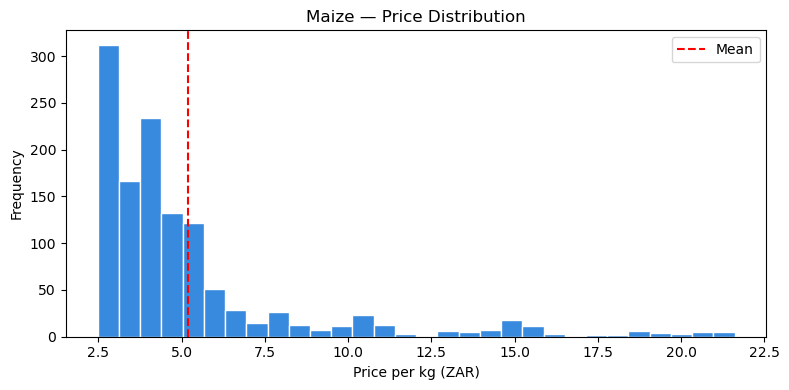

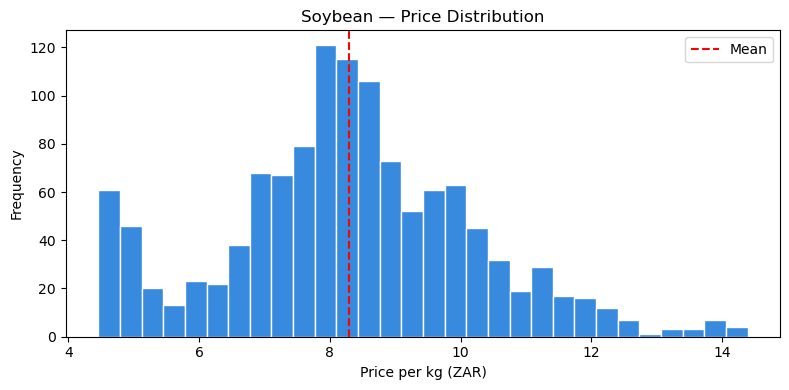

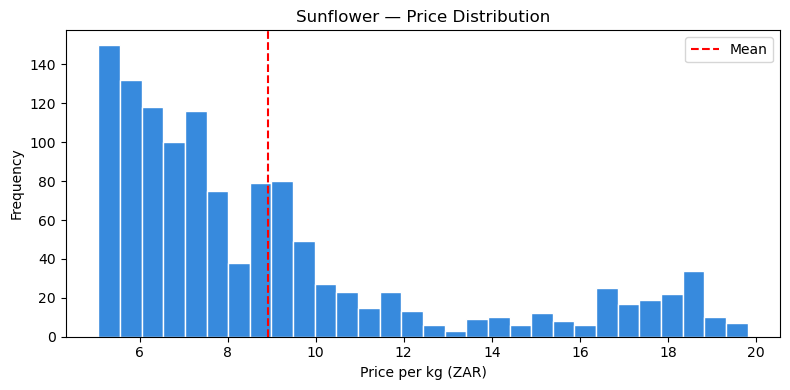

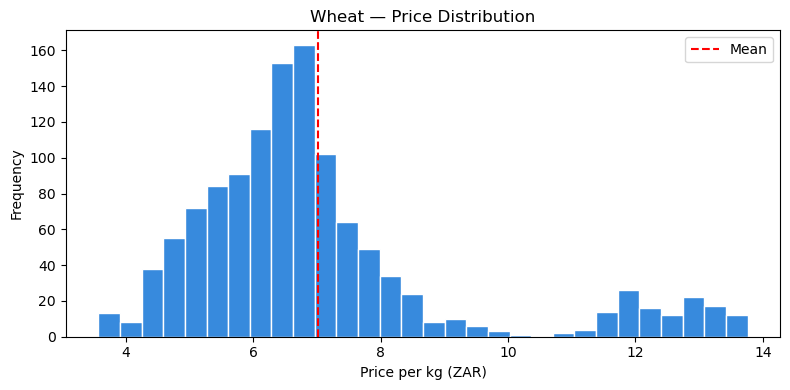

In [5]:

for crop in df["crop"].unique():
    crop_df = df[df["crop"] == crop]
    
    plt.figure(figsize=(8, 4))
    plt.hist(crop_df["price_per_kg"].dropna(), bins=30,
             color="#378ADD", edgecolor="white")
    plt.axvline(crop_df["price_per_kg"].mean(), color="red",
                linestyle="--", label="Mean")
    plt.title(f"{crop} — Price Distribution")
    plt.xlabel("Price per kg (ZAR)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Price Trends Over Time

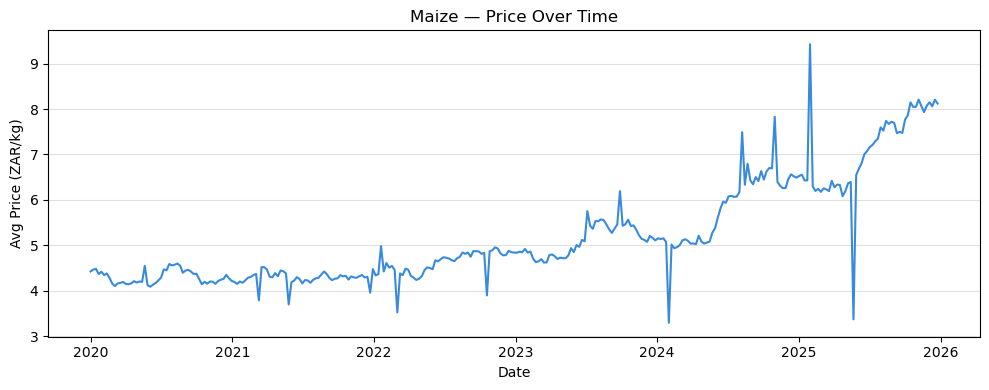

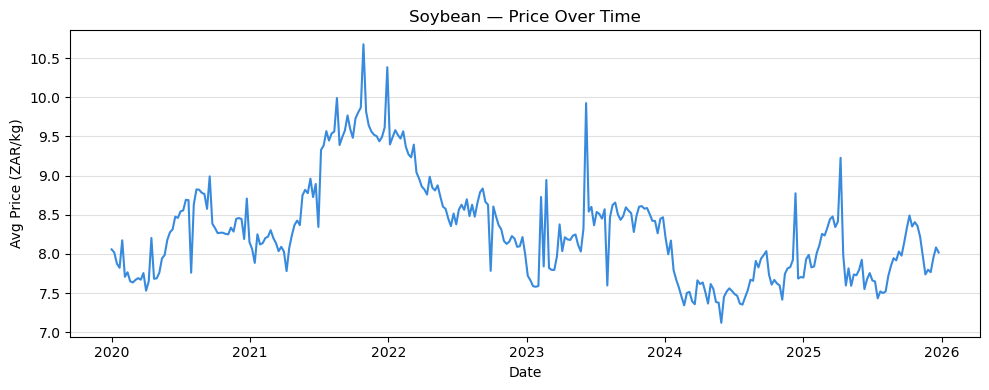

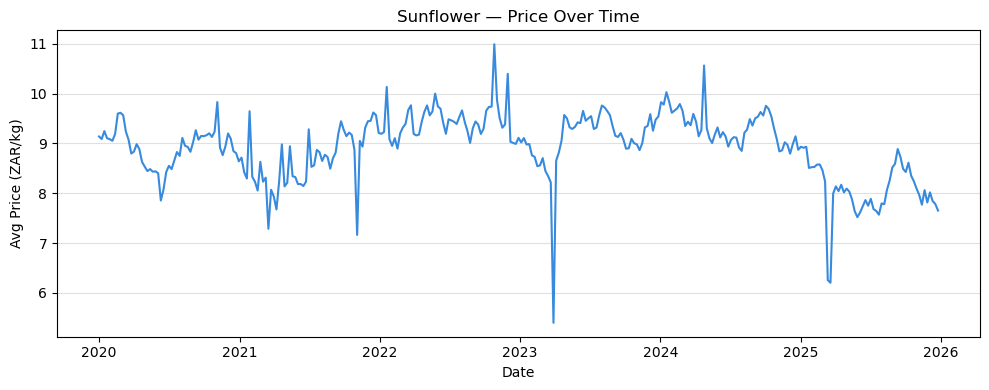

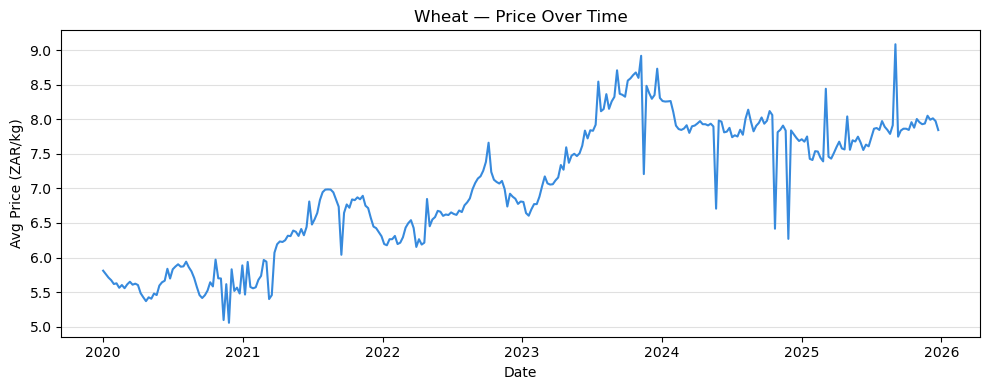

In [6]:
for crop in df["crop"].unique():
    crop_df = df[df["crop"] == crop].groupby("date")["price_per_kg"].mean()

    plt.figure(figsize=(10, 4))
    plt.plot(crop_df.index, crop_df.values, color="#378ADD", linewidth=1.5)
    plt.title(f"{crop} — Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Avg Price (ZAR/kg)")
    plt.grid(axis="y", color="#e0e0e0")
    plt.tight_layout()
    plt.show()

#### Seasonal Price Patterns

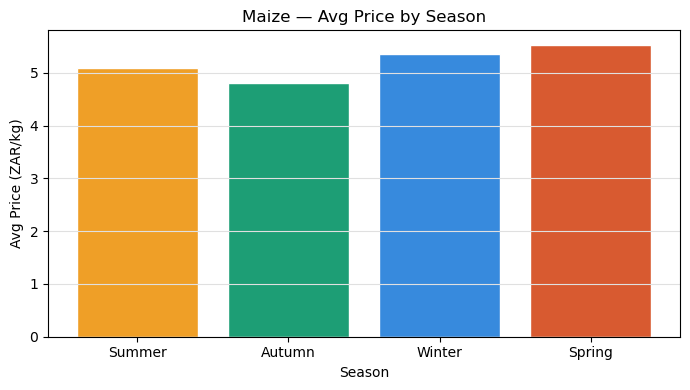

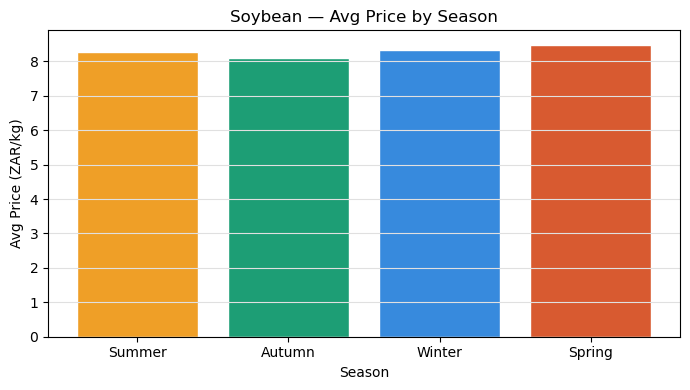

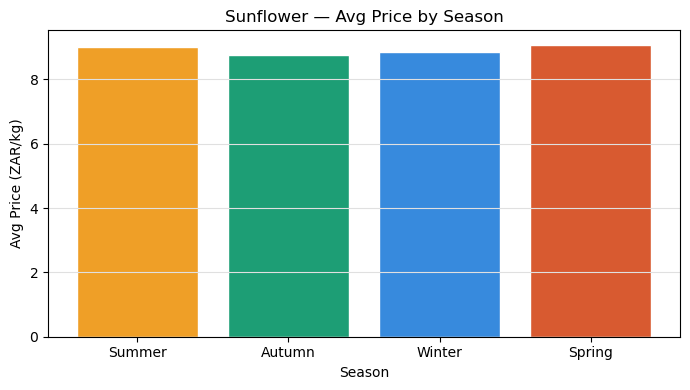

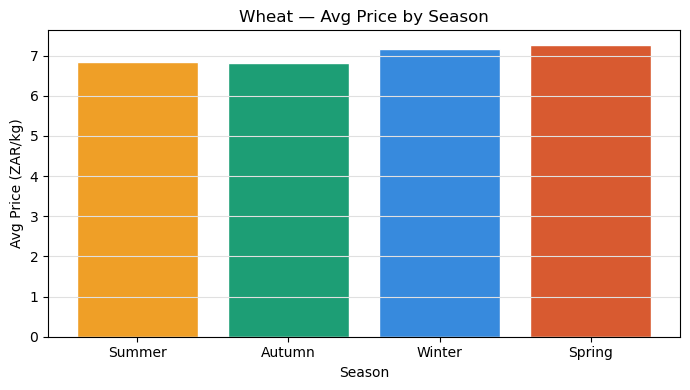

In [7]:
season_order  = ["Summer", "Autumn", "Winter", "Spring"]
season_colors = ["#EF9F27", "#1D9E75", "#378ADD", "#D85A30"]

for crop in df["crop"].unique():
    crop_df    = df[df["crop"] == crop]
    season_avg = crop_df.groupby("season")["price_per_kg"].mean()
    season_avg = season_avg.reindex(season_order)

    plt.figure(figsize=(7, 4))
    plt.bar(season_avg.index, season_avg.values, color=season_colors, edgecolor="white")
    plt.title(f"{crop} — Avg Price by Season")
    plt.xlabel("Season")
    plt.ylabel("Avg Price (ZAR/kg)")
    plt.grid(axis="y", color="#e0e0e0")
    plt.tight_layout()
    plt.show()

#### Correlation Heatmap

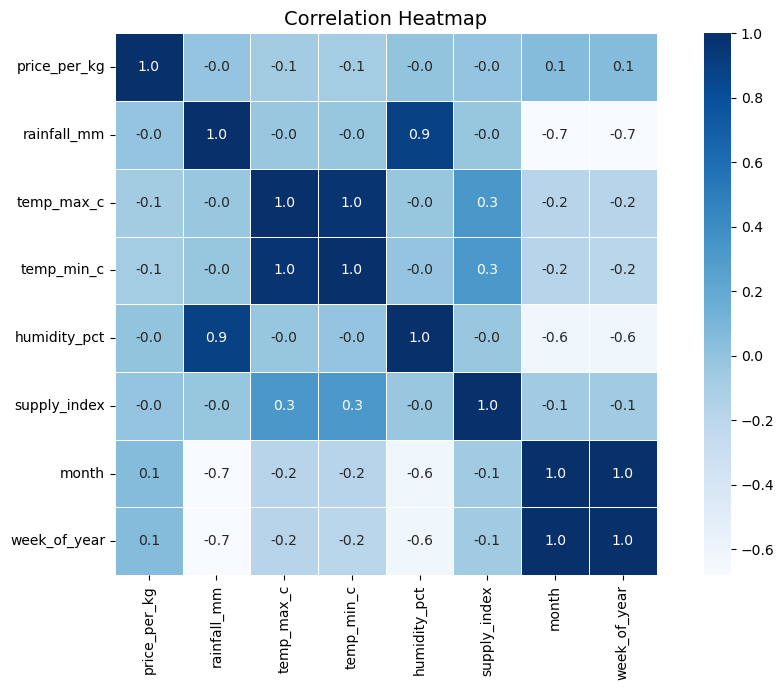

In [8]:
num_cols = ["price_per_kg", "rainfall_mm", "temp_max_c",
            "temp_min_c", "humidity_pct", "supply_index",
            "month", "week_of_year"]

corr = df[num_cols].corr().round(2)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5, square=True)
plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

###  Price by Region

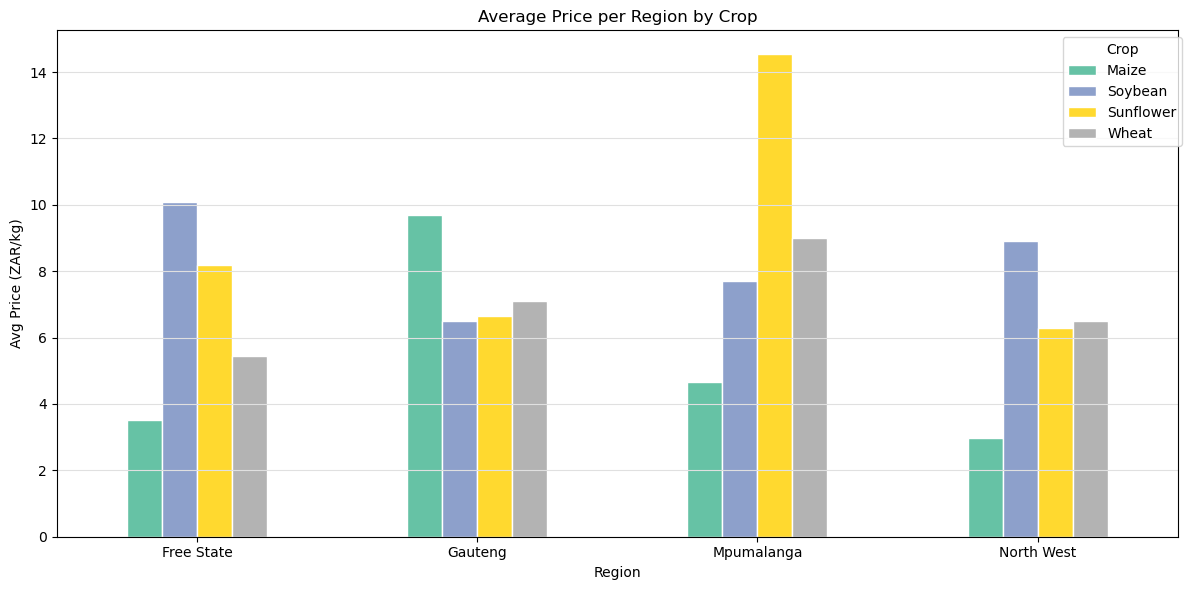

In [9]:
region_avg = df.groupby(["region", "crop"])["price_per_kg"].mean().unstack()

region_avg.plot(kind="bar", figsize=(12, 6), colormap="Set2", edgecolor="white")
plt.title("Average Price per Region by Crop")
plt.xlabel("Region")
plt.ylabel("Avg Price (ZAR/kg)")
plt.xticks(rotation=0)
plt.legend(title="Crop", bbox_to_anchor=(1.01, 1))
plt.grid(axis="y", color="#e0e0e0")
plt.tight_layout()
plt.show()

### Outlier Detection

<Figure size 1200x500 with 0 Axes>

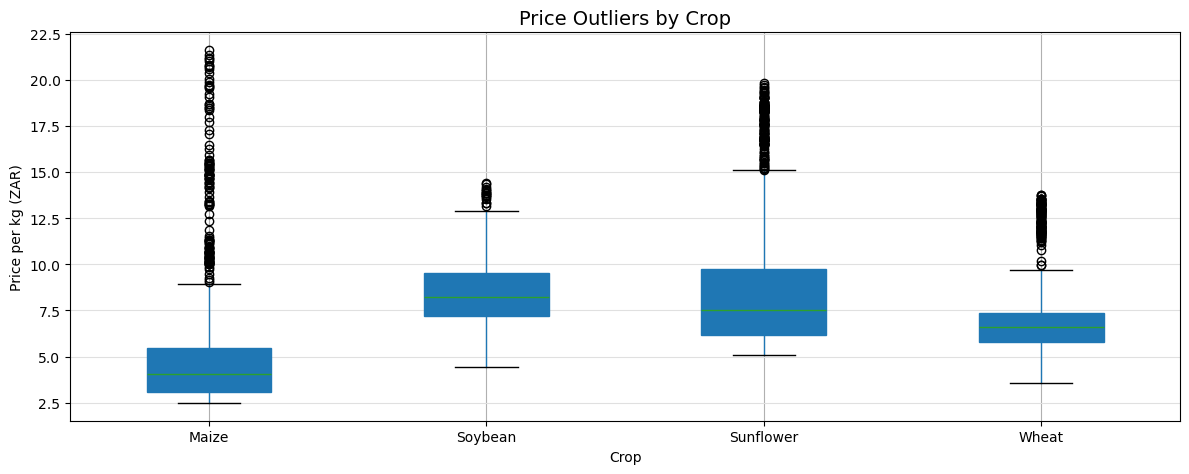

In [10]:
# ── Outlier detection using boxplots ─────────────────────────
plt.figure(figsize=(12, 5))
df.boxplot(column="price_per_kg", by="crop", patch_artist=True, figsize=(12, 5))
plt.suptitle("")
plt.title("Price Outliers by Crop", fontsize=14)
plt.xlabel("Crop")
plt.ylabel("Price per kg (ZAR)")
plt.grid(axis="y", color="#e0e0e0")
plt.tight_layout()
plt.show()

# Step 3 : Display info and check for missing values.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          5008 non-null   datetime64[ns]
 1   year          5008 non-null   int64         
 2   month         5008 non-null   int64         
 3   week_of_year  5008 non-null   int64         
 4   season        5008 non-null   object        
 5   crop          5008 non-null   object        
 6   region        5008 non-null   object        
 7   price_per_kg  4910 non-null   float64       
 8   rainfall_mm   4599 non-null   float64       
 9   temp_max_c    5008 non-null   float64       
 10  temp_min_c    4812 non-null   float64       
 11  humidity_pct  4762 non-null   float64       
 12  supply_index  4872 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 508.8+ KB


#### 2.1 check nulls

In [12]:
def display_info_and_missing_values(df):
    print("Null counts:\n", df.isnull().sum())
    print("\nNull percentage:\n", (df.isnull().sum() / len(df) * 100).round(2))


In [13]:
display_info_and_missing_values(df)

Null counts:
 date              0
year              0
month             0
week_of_year      0
season            0
crop              0
region            0
price_per_kg     98
rainfall_mm     409
temp_max_c        0
temp_min_c      196
humidity_pct    246
supply_index    136
dtype: int64

Null percentage:
 date            0.00
year            0.00
month           0.00
week_of_year    0.00
season          0.00
crop            0.00
region          0.00
price_per_kg    1.96
rainfall_mm     8.17
temp_max_c      0.00
temp_min_c      3.91
humidity_pct    4.91
supply_index    2.72
dtype: float64


#### 2.2 Handle nulls (for rainfall in millimetres, minimum temperature recorded in degrees Celsius, averege humidity percentage, market supply pressure for the crop and the price per kg)



##### For weather columns — fill with the median per region
##### (each region has its own climate so we don't mix them)

In [14]:
weather_cols = ["rainfall_mm", "temp_min_c", "humidity_pct"]
df[weather_cols] = df.groupby("region")[weather_cols].transform(
    lambda x: x.fillna(x.median())
)

display_info_and_missing_values(df[weather_cols])

Null counts:
 rainfall_mm     0
temp_min_c      0
humidity_pct    0
dtype: int64

Null percentage:
 rainfall_mm     0.0
temp_min_c      0.0
humidity_pct    0.0
dtype: float64


#####  For supply_index — fill with median per crop
##### (supply patterns differ per crop)

In [15]:

df["supply_index"] = df.groupby("crop")["supply_index"].transform(
    lambda x: x.fillna(x.median())
)

display_info_and_missing_values(df[["supply_index"]])

Null counts:
 supply_index    0
dtype: int64

Null percentage:
 supply_index    0.0
dtype: float64


#####  For price_per_kg — forward fill within each crop+region group
##### (use the last known price, most realistic for market data)

In [16]:
df["price_per_kg"] = df.groupby(["crop", "region"])["price_per_kg"].transform(
    lambda x: x.ffill().bfill()
)

display_info_and_missing_values(df[["price_per_kg"]])

Null counts:
 price_per_kg    0
dtype: int64

Null percentage:
 price_per_kg    0.0
dtype: float64


### Remaining nulls

In [17]:
print("Remaining nulls:\n", df.isnull().sum())

Remaining nulls:
 date            0
year            0
month           0
week_of_year    0
season          0
crop            0
region          0
price_per_kg    0
rainfall_mm     0
temp_max_c      0
temp_min_c      0
humidity_pct    0
supply_index    0
dtype: int64


# Step 4 — Feature Engineering
Im going to add 4 features:
1.	rolling_7d	- What was the average price this week — is today's price above or below the recent short-term norm?
2.	rolling_30d -	What was the average price over the last month — what is the medium-term trend?
3.	price_delta_7d - How fast is the price moving right now — is it accelerating up or down?
4.	price_delta_30d - Has the price been climbing or falling over the past month overall?

ref: https://www.geeksforgeeks.org/machine-learning/what-is-feature-engineering/

#### Sort first - critical for rolling calculations to be correct 
 - If the dates aren't in order, the rolling window picks up the wrong rows and the features become meaningless. Sorting by crop + region + date ensures each group's prices are in chronological order before the window slides across them.

In [18]:
df = df.sort_values(["crop", "region", "date"]).reset_index(drop=True)
df

,date,year,month,week_of_year,season,crop,region,price_per_kg,rainfall_mm,temp_max_c,temp_min_c,humidity_pct,supply_index
0,2020-01-01,2020,1,1,Summer,Maize,Free State,4.26,4.6,23.0,14.1,51.7,0.330
1,2020-01-08,2020,1,2,Summer,Maize,Free State,4.25,13.2,19.5,11.4,52.7,0.406
2,2020-01-15,2020,1,3,Summer,Maize,Free State,4.31,11.1,20.2,11.6,48.3,0.444
3,2020-01-22,2020,1,4,Summer,Maize,Free State,4.27,23.8,22.2,13.7,57.6,0.523
4,2020-01-29,2020,1,5,Summer,Maize,Free State,4.41,14.0,20.9,11.2,53.4,0.296
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5003,2025-11-26,2025,11,48,Spring,Wheat,North West,7.92,0.0,16.8,7.2,42.4,0.485
5004,2025-12-03,2025,12,49,Summer,Wheat,North West,7.72,0.0,19.7,11.0,27.6,0.551
5005,2025-12-10,2025,12,50,Summer,Wheat,North West,7.45,7.5,19.0,11.0,52.1,0.490
5006,2025-12-17,2025,12,51,Summer,Wheat,North West,7.40,3.9,18.2,10.0,38.8,0.507


###  Rolling averages (7 days and 30 days)
- We group by crop+region as Maize/Gauteng rolls separately from Wheat/FreeState

###   1. rolling_7d

In [19]:
df["rolling_7d"] = df.groupby(["crop", "region"])["price_per_kg"].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
)


### 2. rolling_30d

In [20]:
df["rolling_30d"] = df.groupby(["crop", "region"])["price_per_kg"].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)


### 3. price_delta_7d (% change)

In [21]:
df["price_delta_7d"] = df.groupby(["crop", "region"])["price_per_kg"].transform(
    lambda x: x.pct_change(periods=1).mul(100).round(2)
)


### 4. price_delta_30d (% change)

In [22]:
df["price_delta_30d"] = df.groupby(["crop", "region"])["price_per_kg"].transform(
    lambda x: x.pct_change(periods=4).mul(100).round(2)
)

df.head(5)


,date,year,month,week_of_year,season,crop,region,price_per_kg,rainfall_mm,temp_max_c,temp_min_c,humidity_pct,supply_index,rolling_7d,rolling_30d,price_delta_7d,price_delta_30d
0,2020-01-01,2020,1,1,Summer,Maize,Free State,4.26,4.6,23.0,14.1,51.7,0.330,4.260,4.260000,NaN,NaN
1,2020-01-08,2020,1,2,Summer,Maize,Free State,4.25,13.2,19.5,11.4,52.7,0.406,4.255,4.255000,-0.23,NaN
2,2020-01-15,2020,1,3,Summer,Maize,Free State,4.31,11.1,20.2,11.6,48.3,0.444,4.280,4.273333,1.41,NaN
3,2020-01-22,2020,1,4,Summer,Maize,Free State,4.27,23.8,22.2,13.7,57.6,0.523,4.290,4.272500,-0.93,NaN
4,2020-01-29,2020,1,5,Summer,Maize,Free State,4.41,14.0,20.9,11.2,53.4,0.296,4.340,4.310000,3.28,3.52


In [23]:
df[["date", "crop", "region", "price_per_kg","rolling_7d", "rolling_30d","price_delta_7d", "price_delta_30d"]].head(10)

,date,crop,region,price_per_kg,rolling_7d,rolling_30d,price_delta_7d,price_delta_30d
0,2020-01-01,Maize,Free State,4.26,4.260,4.260000,NaN,NaN
1,2020-01-08,Maize,Free State,4.25,4.255,4.255000,-0.23,NaN
2,2020-01-15,Maize,Free State,4.31,4.280,4.273333,1.41,NaN
3,2020-01-22,Maize,Free State,4.27,4.290,4.272500,-0.93,NaN
4,2020-01-29,Maize,Free State,4.41,4.340,4.310000,3.28,3.52
5,2020-02-05,Maize,Free State,4.24,4.325,4.307500,-3.85,-0.24
6,2020-02-12,Maize,Free State,4.01,4.125,4.232500,-5.42,-6.96
7,2020-02-19,Maize,Free State,3.76,3.885,4.105000,-6.23,-11.94
8,2020-02-26,Maize,Free State,3.47,3.615,3.870000,-7.71,-21.32
9,2020-03-04,Maize,Free State,3.42,3.445,3.665000,-1.44,-19.34


In [24]:
print("\n----Null counts after feature engineering------:\n", df.isnull().sum())


----Null counts after feature engineering------:
 date                0
year                0
month               0
week_of_year        0
season              0
crop                0
region              0
price_per_kg        0
rainfall_mm         0
temp_max_c          0
temp_min_c          0
humidity_pct        0
supply_index        0
rolling_7d          0
rolling_30d         0
price_delta_7d     16
price_delta_30d    64
dtype: int64


### Remove the nulls from the new features added

In [25]:
# ── Drop rows where rolling/delta columns are null ─────────────
df = df.dropna(subset=["price_delta_7d", "price_delta_30d",
                        "rolling_7d", "rolling_30d"])

# ── Confirm ───────────────────────────────────────────────────
print("\nNulls after fix:\n", df.isnull().sum())
print("Remaining rows:", len(df))


Nulls after fix:
 date               0
year               0
month              0
week_of_year       0
season             0
crop               0
region             0
price_per_kg       0
rainfall_mm        0
temp_max_c         0
temp_min_c         0
humidity_pct       0
supply_index       0
rolling_7d         0
rolling_30d        0
price_delta_7d     0
price_delta_30d    0
dtype: int64
Remaining rows: 4944


## Step 5 — Generating the Direction Label(outcome)

In [26]:
# Generate direction label based on future price change (2 weeks ahead)
future_price = df.groupby(["crop", "region"])["price_per_kg"].transform(
    lambda x: x.shift(-2)
)

delta_forward = (future_price - df["price_per_kg"]) / df["price_per_kg"] * 100 # percentage change to determine direction

df["direction"] = pd.cut(
    delta_forward,
    bins=[-np.inf, -3, 3, np.inf], # thresholds for DOWN (<-3%), STABLE (-3% to 3%), UP (>3%)
    labels=["DOWN", "STABLE", "UP"]
)

# Drop last 2 rows of each group (no future price available)
df = df.dropna(subset=["direction"])

# Check label distribution
print("---------Direction counts--------------:\n", df["direction"].value_counts())
print("\n------Direction percentage-----------:\n",
      (df["direction"].value_counts() / len(df) * 100).round(2))

print("\n-------------------------\n")
display_info_and_missing_values(df[["direction"]])

---------Direction counts--------------:
 direction
STABLE    2545
UP        1237
DOWN      1130
Name: count, dtype: int64

------Direction percentage-----------:
 direction
STABLE    51.81
UP        25.18
DOWN      23.00
Name: count, dtype: float64

-------------------------

Null counts:
 direction    0
dtype: int64

Null percentage:
 direction    0.0
dtype: float64


C:\Users\sibus\AppData\Local\Temp\ipykernel_28696\2914229167.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["direction"] = pd.cut(


#### STATE OF THE DATAFRAME BEFORE ENCODING

In [27]:
df.head(10)

,date,year,month,week_of_year,season,crop,region,price_per_kg,rainfall_mm,temp_max_c,temp_min_c,humidity_pct,supply_index,rolling_7d,rolling_30d,price_delta_7d,price_delta_30d,direction
4,2020-01-29,2020,1,5,Summer,Maize,Free State,4.41,14.0,20.9,11.2,53.4,0.296,4.340,4.3100,3.28,3.52,DOWN
5,2020-02-05,2020,2,6,Summer,Maize,Free State,4.24,20.2,27.5,20.2,67.3,0.537,4.325,4.3075,-3.85,-0.24,DOWN
6,2020-02-12,2020,2,7,Summer,Maize,Free State,4.01,14.7,22.4,13.7,48.7,0.456,4.125,4.2325,-5.42,-6.96,DOWN
7,2020-02-19,2020,2,8,Summer,Maize,Free State,3.76,25.0,21.9,12.5,61.2,0.680,3.885,4.1050,-6.23,-11.94,DOWN
8,2020-02-26,2020,2,9,Summer,Maize,Free State,3.47,16.8,26.2,18.9,63.2,0.350,3.615,3.8700,-7.71,-21.32,STABLE
9,2020-03-04,2020,3,10,Autumn,Maize,Free State,3.42,21.2,33.3,26.0,49.4,0.525,3.445,3.6650,-1.44,-19.34,UP
10,2020-03-11,2020,3,11,Autumn,Maize,Free State,3.54,22.8,28.6,20.1,56.3,0.527,3.480,3.5475,3.51,-11.72,DOWN
11,2020-03-18,2020,3,12,Autumn,Maize,Free State,3.60,19.0,28.8,20.7,55.1,0.613,3.570,3.5075,1.69,-4.26,DOWN
12,2020-03-25,2020,3,13,Autumn,Maize,Free State,3.41,32.1,26.2,20.3,62.4,0.440,3.505,3.4925,-5.28,-1.73,DOWN
13,2020-04-01,2020,4,14,Autumn,Maize,Free State,3.20,44.2,34.1,26.5,76.4,0.522,3.305,3.4375,-6.16,-6.43,STABLE


## Step 6 — Encoding Categorical Columns

In [28]:
# Check which columns are categorical 
print("Column types:\n", df.dtypes)

Column types:
 date               datetime64[ns]
year                        int64
month                       int64
week_of_year                int64
season                     object
crop                       object
region                     object
price_per_kg              float64
rainfall_mm               float64
temp_max_c                float64
temp_min_c                float64
humidity_pct              float64
supply_index              float64
rolling_7d                float64
rolling_30d               float64
price_delta_7d            float64
price_delta_30d           float64
direction                category
dtype: object


In [29]:
#  Encode categorical columns 
le_crop = LabelEncoder()
le_region = LabelEncoder()
le_season = LabelEncoder()
le_direction = LabelEncoder()

df["crop"]      = le_crop.fit_transform(df["crop"])
df["region"]    = le_region.fit_transform(df["region"])
df["season"]    = le_season.fit_transform(df["season"])
df["direction"] = le_direction.fit_transform(df["direction"].astype(str))

#### STATE OF THE DATAFRAME AFTER CATEGORICAL COLUMNS ENCODING

In [30]:
df

,date,year,month,week_of_year,season,crop,region,price_per_kg,rainfall_mm,temp_max_c,temp_min_c,humidity_pct,supply_index,rolling_7d,rolling_30d,price_delta_7d,price_delta_30d,direction
4,2020-01-29,2020,1,5,2,0,0,4.41,14.0,20.9,11.2,53.4,0.296,4.340,4.3100,3.28,3.52,0
5,2020-02-05,2020,2,6,2,0,0,4.24,20.2,27.5,20.2,67.3,0.537,4.325,4.3075,-3.85,-0.24,0
6,2020-02-12,2020,2,7,2,0,0,4.01,14.7,22.4,13.7,48.7,0.456,4.125,4.2325,-5.42,-6.96,0
7,2020-02-19,2020,2,8,2,0,0,3.76,25.0,21.9,12.5,61.2,0.680,3.885,4.1050,-6.23,-11.94,0
8,2020-02-26,2020,2,9,2,0,0,3.47,16.8,26.2,18.9,63.2,0.350,3.615,3.8700,-7.71,-21.32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5001,2025-11-12,2025,11,46,1,3,3,7.38,0.0,16.4,6.9,44.1,0.399,7.355,7.3225,0.68,4.68,2
5002,2025-11-19,2025,11,47,1,3,3,7.60,0.0,21.8,12.9,39.2,0.721,7.490,7.4100,2.98,4.83,1
5003,2025-11-26,2025,11,48,1,3,3,7.92,0.0,16.8,7.2,42.4,0.485,7.760,7.5575,4.21,8.05,0
5004,2025-12-03,2025,12,49,2,3,3,7.72,0.0,19.7,11.0,27.6,0.551,7.820,7.6550,-2.53,5.32,0


#### WHAT EACH COLUMN VALUE BECOMES

In [31]:
print("\nCrop encoding:     ", dict(zip(le_crop.classes_,
                                le_crop.transform(le_crop.classes_))))
print("Region encoding:   ", dict(zip(le_region.classes_,
                                le_region.transform(le_region.classes_))))
print("Season encoding:   ", dict(zip(le_season.classes_,
                                le_season.transform(le_season.classes_))))
print("Direction encoding:", dict(zip(le_direction.classes_,
                                le_direction.transform(le_direction.classes_))))


Crop encoding:      {'Maize': 0, 'Soybean': 1, 'Sunflower': 2, 'Wheat': 3}
Region encoding:    {'Free State': 0, 'Gauteng': 1, 'Mpumalanga': 2, 'North West': 3}
Season encoding:    {'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}
Direction encoding: {'DOWN': 0, 'STABLE': 1, 'UP': 2}


## Step 7 — Splitting into Train & Test Sets


####  features and target

In [38]:
FEATURES = [
    "crop", "region", "month", "season",
    "price_per_kg", "rainfall_mm", "temp_max_c", "temp_min_c",
    "humidity_pct", "supply_index",
    "rolling_7d", "rolling_30d",
    "price_delta_7d", "price_delta_30d"
]

TARGET = "direction"


X = df[FEATURES]
y = df[TARGET]



#### Time-based split

In [41]:
split_idx = int(len(df) * 0.80) # 80% for training, 20% for testing 


X_train = X.iloc[:split_idx] # first 80% of rows for training
X_test  = X.iloc[split_idx:] # remaining 20% for testing
y_train = y.iloc[:split_idx] # first 80% of rows for training
y_test  = y.iloc[split_idx:] # remaining 20% for testing



#### Confirm sizes

In [45]:
print("Total rows     :", len(df))
print("Training rows  :", len(X_train))
print("Testing rows   :", len(X_test))
print("\nTraining %     :", round(len(X_train) / len(df) * 100, 1))
print("Testing  %     :", round(len(X_test)  / len(df) * 100, 1))

print("\nX_train shape  :", X_train.shape)
print("X_test shape   :", X_test.shape)

print("\nTraining date range:", df["date"].iloc[0], "-", df["date"].iloc[split_idx - 1])
print("Testing  date range:", df["date"].iloc[split_idx], "-", df["date"].iloc[-1])

Total rows     : 4912
Training rows  : 3929
Testing rows   : 983

Training %     : 80.0
Testing  %     : 20.0

X_train shape  : (3929, 14)
X_test shape   : (983, 14)

Training date range: 2020-01-29 00:00:00 - 2024-10-02 00:00:00
Testing  date range: 2024-10-09 00:00:00 - 2025-12-10 00:00:00


## Step 8 — Scaling the Features

In [47]:
scaler = StandardScaler()

#Fit on training data only, then transform both set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Confirm 
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

print("\nBefore scaling — price_per_kg sample:")
print(X_train["price_per_kg"].head().values)

print("\nAfter scaling — price_per_kg sample:")
print(X_train_scaled[:5, X_train.columns.get_loc("price_per_kg")])

X_train_scaled shape: (3929, 14)
X_test_scaled shape : (983, 14)

Before scaling — price_per_kg sample:
[4.41 4.24 4.01 3.76 3.47]

After scaling — price_per_kg sample:
[-0.83699042 -0.8852276  -0.95048966 -1.02142668 -1.10371362]
